## Introduction to Forecasting
In the previous section we fit various smoothing models to existing data. The purpose behind this is to predict what happens next.<br>
What's our best guess for next month's value? For the next six months?

In this section we'll look to extend our models into the future. First we'll divide known data into training and testing sets, and evaluate the performance of a trained model on known test data.

* Goals
  * Compare a Holt-Winters forecasted model to known data
  * Understand <em>stationarity</em>, <em>differencing</em> and <em>lagging</em>
  * Introduce ARIMA and describe next steps

#### <font color=blue>Simple Exponential Smoothing / Simple Moving Average</font>
This is the simplest to forecast. $\hat{y}$ is equal to the most recent value in the dataset, and the forecast plot is simply a horizontal line extending from the most recent value.
#### <font color=blue>Double Exponential Smoothing / Holt's Method</font>
This model takes trend into account. Here the forecast plot is still a straight line extending from the most recent value, but it has slope.
#### <font color=blue>Triple Exponential Smoothing / Holt-Winters Method</font>
This model has (so far) the "best" looking forecast plot, as it takes seasonality into account. When we expect regular fluctuations in the future, this model attempts to map the seasonal behavior.

### Forecasting with the Holt-Winters Method
For this example we'll use the same airline_passengers dataset, and we'll split the data into 108 training records and 36 testing records. Then we'll evaluate the performance of the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("Data/airline_passengers.csv", index_col="Month", parse_dates=True)

In [4]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [5]:
df.index.freq = "MS"

In [6]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [7]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
df.tail()

,Thousands of Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Thousands of Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Thousands of Passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


##### Split into Train and Test

In [17]:
df.count()

Thousands of Passengers    144
dtype: int64

In [12]:
train_df = df.iloc[:108]
test_df = df.iloc[108:]

In [15]:
train_df.count()

Thousands of Passengers    108
dtype: int64

In [16]:
test_df.count()

Thousands of Passengers    36
dtype: int64

#### Holt-Winters Models

In [38]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [43]:
fitted_model = ExponentialSmoothing(
    train_df["Thousands of Passengers"], trend="mul", seasonal="mul", seasonal_periods=12
).fit()

In [44]:
test_predictions = fitted_model.forecast(36)

In [45]:
test_predictions

1958-01-01    356.968595
1958-02-01    344.588783
1958-03-01    405.718335
1958-04-01    400.610851
1958-05-01    409.001722
1958-06-01    480.694297
1958-07-01    530.470162
1958-08-01    523.288648
1958-09-01    454.210635
1958-10-01    392.518142
1958-11-01    345.928422
1958-12-01    396.605187
1959-01-01    408.958923
1959-02-01    394.776065
1959-03-01    464.808769
1959-04-01    458.957410
1959-05-01    468.570361
1959-06-01    550.704528
1959-07-01    607.729948
1959-08-01    599.502490
1959-09-01    520.363679
1959-10-01    449.686046
1959-11-01    396.310814
1959-12-01    454.368345
1960-01-01    468.521328
1960-02-01    452.272822
1960-03-01    532.505368
1960-04-01    525.801794
1960-05-01    536.814814
1960-06-01    630.911328
1960-07-01    696.242157
1960-08-01    686.816419
1960-09-01    596.151517
1960-10-01    515.180112
1960-11-01    454.031099
1960-12-01    520.544360
Freq: MS, dtype: float64

<Axes: xlabel='Month'>

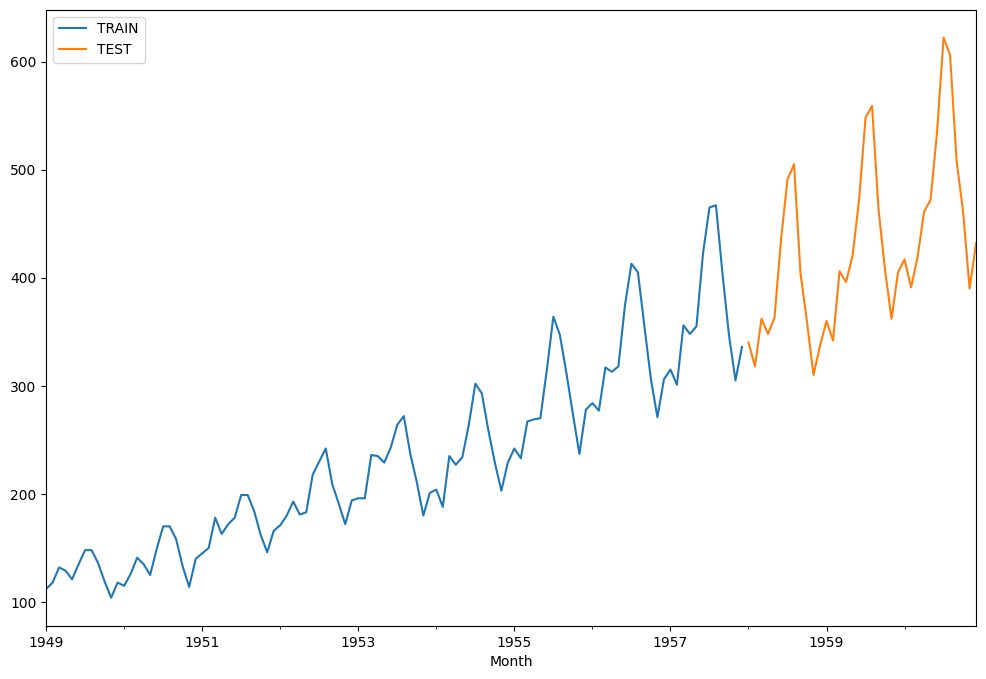

In [46]:
train_df["Thousands of Passengers"].plot(legend=True, label="TRAIN")
test_df["Thousands of Passengers"].plot(legend=True, label="TEST", figsize=(12, 8))

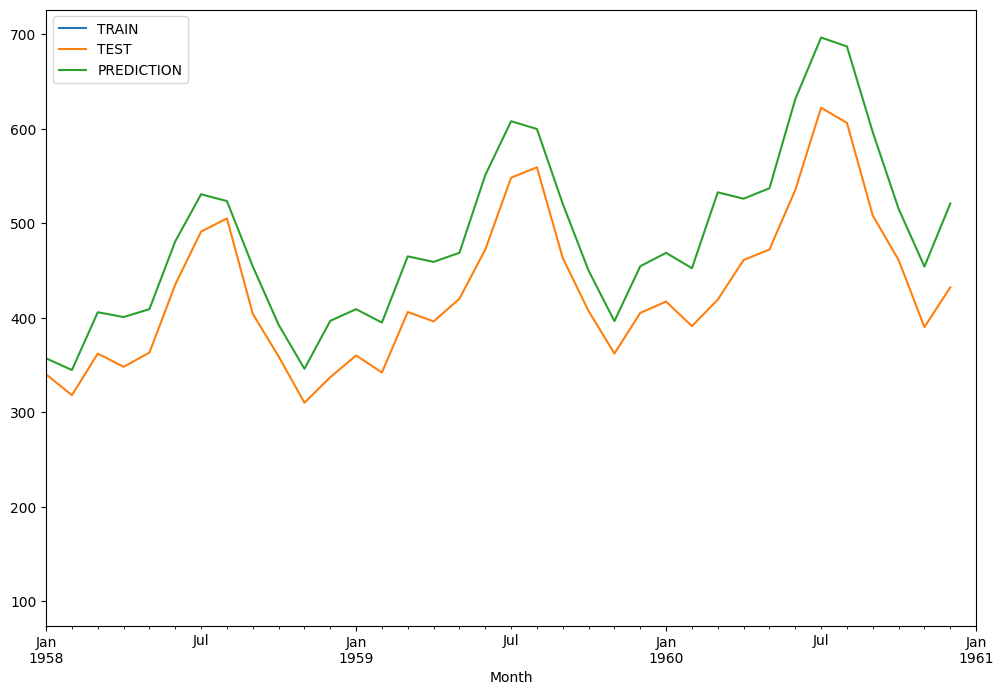

In [49]:
train_df["Thousands of Passengers"].plot(legend=True, label="TRAIN")
test_df["Thousands of Passengers"].plot(legend=True, label="TEST", figsize=(12, 8))
test_predictions.plot(legend=True, label="PREDICTION", xlim=["1958-01-01", "1961-01-01"]);

#### Evaluation Metrics

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [57]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Thousands of Passengers,36.0,428.5,79.329152,310.0,362.0,412.0,472.0,622.0


In [58]:
mean_absolute_error(test_df, test_predictions)

55.69817426250305

In [59]:
mean_squared_error(test_df, test_predictions)

3525.9134388101156

In [61]:
np.sqrt(mean_squared_error(test_df, test_predictions))

np.float64(59.379402479396134)

#### Final model on entire data

In [63]:
final_model = ExponentialSmoothing(
    df["Thousands of Passengers"], trend="mul", seasonal="mul", seasonal_periods=12
).fit()

In [64]:
forecast_predictions = final_model.forecast(36)

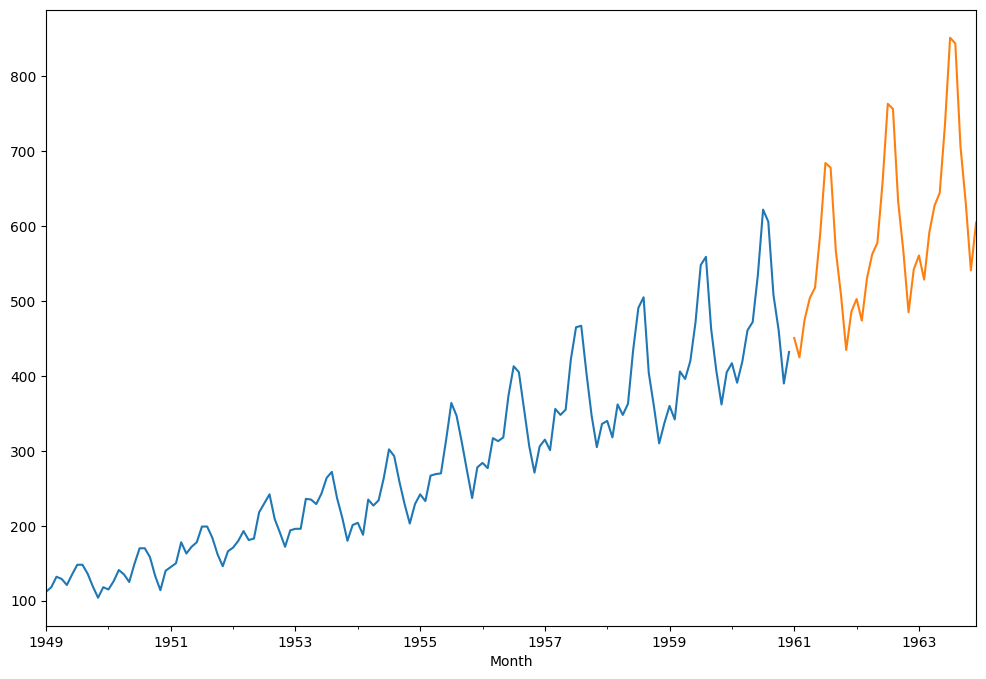

In [65]:
df['Thousands of Passengers'].plot(figsize=(12,8))
forecast_predictions.plot();

# Stationarity
Time series data is said to be <em>stationary</em> if it does <em>not</em> exhibit trends or seasonality. That is, the mean, variance and covariance should be the same for any segment of the series, and are not functions of time.<br>
The file <tt>samples.csv</tt> contains made-up datasets that illustrate stationary and non-stationary data.

<div class="alert alert-info"><h3>For Further Reading:</h3>
<strong>
<a href='https://otexts.com/fpp2/stationarity.html'>Forecasting: Principles and Practice</a></strong>&nbsp;&nbsp;<font color=black>Stationarity and differencing</font></div>

In [66]:
df2 = pd.read_csv("Data/samples.csv", index_col=0, parse_dates=True)
df2.head()

,a,b,c,d
1950-01-01,36,27,0,67
1950-02-01,58,22,3,31
1950-03-01,61,17,5,67
1950-04-01,37,15,8,47
1950-05-01,66,13,8,62


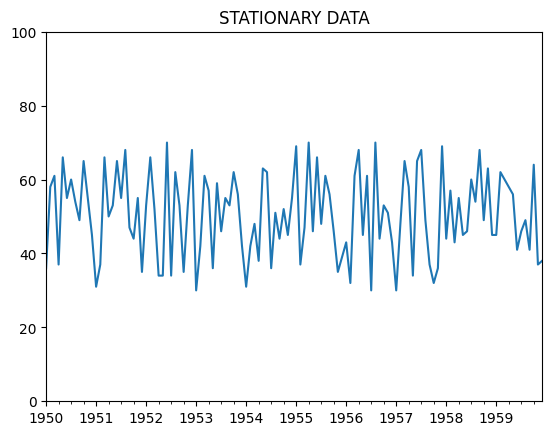

In [70]:
df2['a'].plot(ylim=[0,100],title="STATIONARY DATA").autoscale(axis='x',tight=True);

# This is Stationary Data.
# Stationary data does not exhibit trends and seasonality.

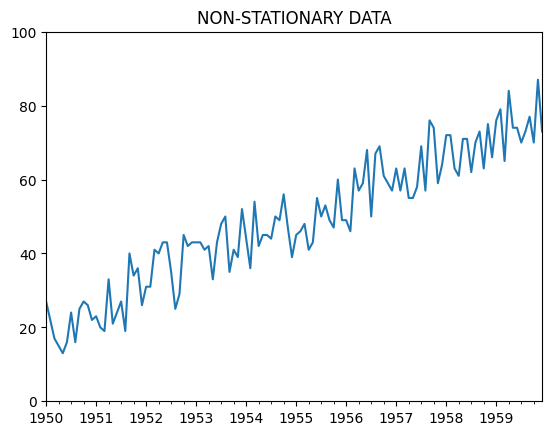

In [72]:
df2['b'].plot(ylim=[0,100],title="NON-STATIONARY DATA").autoscale(axis='x',tight=True);

# Non-stationary data shows either a trend or seasonality or both.

In [ ]:
df2['c'].plot(ylim=[0,10000],title="MORE NON-STATIONARY DATA").autoscale(axis='x',tight=True);

# Differencing
## First Order Differencing
Non-stationary data can be made to look stationary through <em>differencing</em>. A simple method called <em>first order differencing</em> calculates the difference between consecutive observations.

&nbsp;&nbsp;&nbsp;&nbsp;$y^{\prime}_t = y_t - y_{t-1}$

In this way a linear trend is transformed into a horizontal set of values.


In [73]:
from statsmodels.tsa.statespace.tools import diff

In [74]:
df2["b"] - df2["b"].shift(1)

1950-01-01     NaN
1950-02-01    -5.0
1950-03-01    -5.0
1950-04-01    -2.0
1950-05-01    -2.0
              ... 
1959-08-01     3.0
1959-09-01     4.0
1959-10-01    -7.0
1959-11-01    17.0
1959-12-01   -14.0
Name: b, Length: 120, dtype: float64

In [75]:
diff(df2["b"], k_diff=1)

1950-02-01    -5.0
1950-03-01    -5.0
1950-04-01    -2.0
1950-05-01    -2.0
1950-06-01     3.0
              ... 
1959-08-01     3.0
1959-09-01     4.0
1959-10-01    -7.0
1959-11-01    17.0
1959-12-01   -14.0
Name: b, Length: 119, dtype: float64

<Axes: >

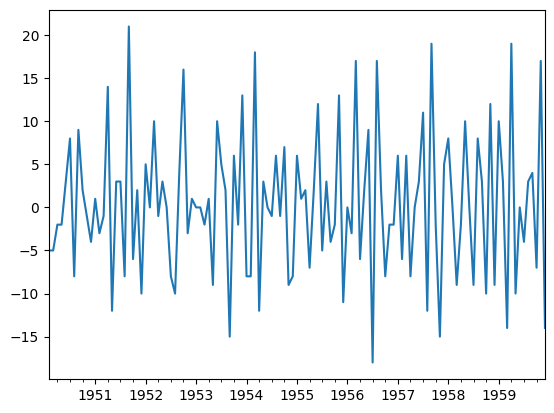

In [77]:
diff(df2["b"], k_diff=1).plot()
# any seasonality

In [ ]:
# exhibit: sergilemek

# notice: fark etme, dikkat, uyarı 


# decomposition: ayrıştırma
# residual: rizicuıl: artık, kalan
# lag: gecikme duraklam geri kalma